<a href="https://colab.research.google.com/github/marisolriveraslrzn/CodingIA/blob/main/ROCK%E2%80%93PAPER%E2%80%93SCISSORS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ROCK–PAPER–SCISSORS LIVE GAME

1. Importing libraries

In [59]:
# standard libraries
import os, sys, time, glob, random, base64, shutil, pathlib, io, json   #maneja archivos, rutas y datos
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

# Colab display
from IPython.display import Javascript, display, Audio, Image as DImage
from google.colab.output import eval_js

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from tensorflow.keras.models import load_model
print("TF:", tf.__version__)

TF: 2.20.0


2. Environment configuration /Configuración del entorno

In [60]:
# Configurar el entorno del proyecto [PENDIENTE]
#Configuracion de carpetas del proyecto
BASE_DIR = "/content/project_rps"
RAW_DIR = BASE_DIR + "/raw"        #aqui  se toman las fotos
DATA_DIR = BASE_DIR + "/data"

#CATEGORIAS
CATEGORIES = ["Rock", "Paper", "Scissors"]

IMG_SIZE = (224, 224)
TRAIN_RATIO = 0.8     #80% train, 20% test


for c in CATEGORIES:
    os.makedirs(os.path.join(RAW_DIR, c), exist_ok = True)


print("Categorias: ",CATEGORIES)
print("RAW_DIR: ",RAW_DIR)

Categorias:  ['Rock', 'Paper', 'Scissors']
RAW_DIR:  /content/project_rps/raw


3. Data collection function (using JavaScript)

In [61]:
# Cámara web con JavaScript: toma de múltiples fotos para una categoría seleccionada

def collect_samples(category, min_count=20, quality=0.9, mirror=True):
    # simple JS GUI: botones "Tomar foto" y "Finalizar".
    target = os.path.join(RAW_DIR, category)
    os.makedirs(target, exist_ok=True)

    js = Javascript('''
      async function session(minCount, q) {
        const div = document.createElement('div');
        const btn = document.createElement('button');
        btn.textContent = 'Take photo';
        btn.style.fontSize = '16px';
        btn.style.marginRight = '8px';

        const done = document.createElement('button');
        done.textContent = 'Finish';
        done.disabled = true;

        const info = document.createElement('span');
        info.style.marginLeft = '10px';
        info.textContent = '0 / ' + minCount;

        div.appendChild(btn);
        div.appendChild(done);
        div.appendChild(info);

        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.maxWidth = '480px';

        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        const images = [];
        btn.onclick = () => {
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          images.push(canvas.toDataURL('image/jpeg', q));

          info.textContent = images.length + ' / ' + minCount;
          if (images.length >= minCount) done.disabled = false;
        };

        await new Promise(resolve => done.onclick = resolve);

        stream.getTracks().forEach(t => t.stop());
        div.remove();

        return images;
      }
    ''')

    display(js)
    data_urls = eval_js(f"session({min_count}, {quality})")

    saved_count = 0

    for i, data_url in enumerate(data_urls):
        raw = base64.b64decode(data_url.split(',')[1])
        fname = os.path.join(
            target,
            f"{category}_{int(time.time()*1000)}_{i:03d}.jpg"
        )
        with open(fname, 'wb') as f:
            f.write(raw)
        saved_count += 1

        if mirror:
            img = Image.open(io.BytesIO(raw)).convert('RGB')
            img = ImageOps.mirror(img)

            fname_mirror = os.path.join(
                target,
                f"{category}_{int(time.time()*1000)}_{i:03d}_m.jpg"
            )
            img.save(fname_mirror, "JPEG", quality=int(quality * 100))
            saved_count += 1

    print("Saved:", saved_count, "files to", target)

4. Recopilación de datos para el modelo

In [67]:
# Para cada clase, llama a la función de recopilación de datos
collect_samples("Paper", min_count=50, mirror=True)

<IPython.core.display.Javascript object>

Saved: 118 files to /content/project_rps/raw/Paper


In [68]:
collect_samples("Rock", min_count=50, mirror=True)

<IPython.core.display.Javascript object>

Saved: 112 files to /content/project_rps/raw/Rock


In [69]:
collect_samples("Scissors", min_count=50, mirror=True)

<IPython.core.display.Javascript object>

Saved: 100 files to /content/project_rps/raw/Scissors


5. Dividir los datos

In [ ]:
# División de entrenamiento/prueba: copiar imágenes en carpetas específicas

def split_train_test():
    if os.path.exists(DATA_DIR):
        shutil.rmtree(DATA_DIR)

    for split in ["train", "test"]:
        for c in CATEGORIES:
            os.makedirs(os.path.join(DATA_DIR, split, c), exist_ok=True)

    for c in CATEGORIES:
        files = glob.glob(os.path.join(RAW_DIR, c, "*"))
        files = [p for p in files if os.path.isfile(p)]
        random.shuffle(files)

        n = len(files)
        n_train = int(n * TRAIN_RATIO)

        train_files = files[:n_train]
        test_files  = files[n_train:]

        for src in train_files:
            shutil.copy2(src, os.path.join(DATA_DIR, "train", c, os.path.basename(src)))

        for src in test_files:
            shutil.copy2(src, os.path.join(DATA_DIR, "test", c, os.path.basename(src)))

    print("Data saved to", DATA_DIR)

In [70]:
    split_train_test()

Data saved to /content/project_rps/data


6. Cargando datos y entrenando el modelo.

Found 435 files belonging to 3 classes.
Found 111 files belonging to 3 classes.
class_names: ['Paper', 'Rock', 'Scissors']


/tmp/ipykernel_2744/4101168951.py:37: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, input_tensor=x, weights="imagenet", pooling="avg")


Epoch 1/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6391 - loss: 0.7951 - val_accuracy: 0.8919 - val_loss: 0.4050
Epoch 2/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9379 - loss: 0.2766 - val_accuracy: 0.9550 - val_loss: 0.2199
Epoch 3/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9770 - loss: 0.1502 - val_accuracy: 0.9640 - val_loss: 0.1415
Epoch 4/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9839 - loss: 0.0955 - val_accuracy: 0.9730 - val_loss: 0.1168
Epoch 5/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.9954 - loss: 0.0708 - val_accuracy: 0.9820 - val_loss: 0.1015
Epoch 6/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9954 - loss: 0.0563 - val_accuracy: 0.9820 - val_loss: 0.0886
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 941ms/step - accuracy: 0.9820 - loss: 0.0886
Test acc: 0.9819819927215576


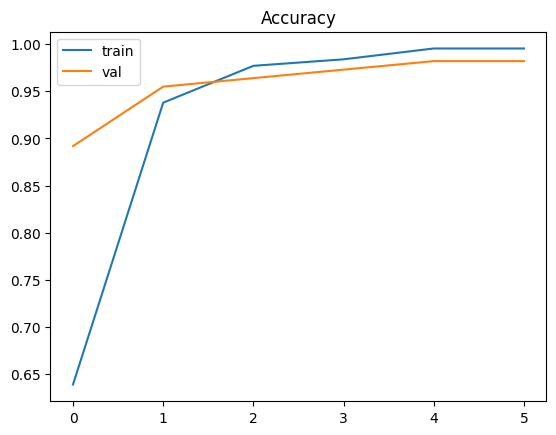

In [71]:
# Funciones para cargar datos y construir el modelo
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def load_data():
    train_ds = image_dataset_from_directory(
        os.path.join(DATA_DIR, "train"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=True
    )

    test_ds = image_dataset_from_directory(
        os.path.join(DATA_DIR, "test"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=False
    )

    return (
        train_ds.prefetch(AUTOTUNE),
        test_ds.prefetch(AUTOTUNE),
        train_ds.class_names
    )

def build_model(n_classes):

    # model robustness
    input = layers.Input(shape=IMG_SIZE + (3,))
    x = layers.RandomFlip("horizontal")(input)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.1)(x)
    x = mnv2_preprocess(x)

    base = MobileNetV2(include_top=False, input_tensor=x, weights="imagenet", pooling="avg")
    base.trainable = False

    x = layers.Dropout(0.2)(base.output)
    output = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(input, output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Train the model
train_ds, test_ds, class_names = load_data()
print("class_names:", class_names)

model = build_model(len(class_names))
hist = model.fit(train_ds, validation_data=test_ds, epochs=6)
loss, acc = model.evaluate(test_ds)
print("Test acc:", acc)

plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='val')
plt.legend(); plt.title("Accuracy"); plt.show()

7. LIVE prediction from the webcam

In [72]:
# Webcam prediction
def take_photo(filename="photo.jpg", quality=0.9):
    js = Javascript('''
      async function f(q) {
        const div = document.createElement('div');
        const b = document.createElement('button');
        b.textContent = 'Take photo';
        b.style.fontSize = '16px';
        b.style.marginBottom = '8px';
        div.appendChild(b);

        const video = document.createElement('video');
        video.style.display='block';
        video.style.maxWidth='480px';
        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise(resolve => b.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(t => t.stop());
        div.remove();
        return canvas.toDataURL('image/jpeg', q);
      }
    ''')
    display(js)
    data = eval_js(f"f({quality})")
    raw = base64.b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(raw)
    return filename


def prepare_image(path, size=IMG_SIZE, mirror=False):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    m = min(w, h)

    # Center-crop to square
    img = img.crop(((w - m) // 2, (h - m) // 2, (w + m) // 2, (h + m) // 2)).resize(size)

    if mirror:
        img = ImageOps.mirror(img)

    x = np.asarray(img).astype("float32")
    x = np.expand_dims(x, 0)  # (1, H, W, 3) – preprocessing is done inside the MODEL
    return x

Webcam + classification function

In [ ]:
# TOP3 function
def predict_top3(path, mirror=False, topk=3):
    x = prepare_image(path, mirror=mirror)
    p = model.predict(x, verbose=0)[0]
    idx = int(np.argmax(p))
    label = class_names[idx]              # raw label (folder name)
    title = label.replace("_"," ").title()
    confidence = float(p[idx])

    print(f"Predicted: {title} ({label}), confidence: {confidence:.2f}")
    top = np.argsort(p)[-topk:][::-1]
    print("Top-3:")
    for i in top:
        print(f"  {class_names[i]}: {p[i]:.3f}")

In [ ]:
# Function call [TO DO]
photo = take_photo("photo.jpg")
predict_top3(photo, mirror=False)

<IPython.core.display.Javascript object>

Predicted: Scissors (Scissors), confidence: 0.65
Top-3:
  Scissors: 0.648
  Rock: 0.352
  Paper: 0.000


PARTE 2: AUTOMATIZAR JUEGO

In [ ]:
# CUENTA REGRESIVA DE 3 SEGUNDOS + FOTO AUTOMÁTICA
def take_photo_countdown_3s(filename="photo_3s.jpg", quality=0.9):
    js = Javascript('''
      async function snap3s(q){
        const video = document.createElement('video');
        const btn = document.createElement('button');
        const overlay = document.createElement('div');

        btn.textContent = 'Iniciar';
        video.style.maxWidth = '480px';
        overlay.style.cssText = `
          position:fixed;left:0;top:0;right:0;bottom:0;
          display:flex;align-items:center;justify-content:center; text-align:center;
          font-size:120px;font-weight:700;color:white;
          background:rgba(80,5,52,0.35);z-index:999999;visibility:hidden;
        `;

        document.body.append(video, btn, overlay);

        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise(r => btn.onclick = r);

        overlay.style.visibility = 'visible';
        for (let s = 3; s >= 1; s--) {
          overlay.textContent = s;
          await new Promise(r => setTimeout(r, 1000));
        }
        overlay.textContent = '¡YA!';
        await new Promise(r => setTimeout(r, 250));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(t => t.stop());
        video.remove(); btn.remove(); overlay.remove();

        return canvas.toDataURL('image/jpeg', q);
      }
    ''')
    display(js)
    data = eval_js(f'snap3s({quality})')
    raw = base64.b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(raw)
    return filename

In [80]:
!pip -q install gTTS
from gtts import gTTS
from IPython.display import Audio, display
import uuid, os

In [ ]:
def say(text, lang='en', slow=False, autoplay=True, prefix="tts"):
    """
    Text-to-speech with gTTS and (optional) playback in the notebook.
    Returns the path to the generated MP3 file.
    """
    fname = f"{prefix}_{uuid.uuid4().hex[:8]}.mp3"
    gTTS(text=text, lang=lang, slow=slow).save(fname)
    if autoplay:
        display(Audio(filename=fname, autoplay=True))
    return fname

In [ ]:
# Configuración del juego
MOVES = ["Paper", "Rock", "Scissors"]
SCORE = {"player": 0, "computer": 0, "tie": 0}

# Lógica ganadora
def who_wins(player, comp):
    if player == comp:
        return "tie"
    if (player == "Rock"  and comp == "Scissors") or \
       (player == "Scissors" and comp == "Paper") or \
       (player == "Paper" and comp == "Rock"):
        return "player"
    return "computer"

# Predice el movimiento del jugador a partir de una foto
def predict_move_from_photo(path, mirror=False):
    x = prepare_image(path, mirror=mirror)
    p = model.predict(x, verbose=0)[0]
    idx = int(np.argmax(p))
    label = class_names[idx]
    return label

# Bucle de 3 vueltas
say("Starting the game. Three rounds: Paper, Rock, Scissors!", autoplay=True)

for round_num in range(1, 4):
    print(f"\n=== ROUND {round_num} / 3 ===")

    path = take_photo_countdown_3s(f"game{round_num}.jpg", quality=0.9)

    player = predict_move_from_photo(path, mirror=False)
    comp = random.choice(MOVES)

    result = who_wins(player, comp)
    SCORE[result] += 1

    print("===== PAPER • ROCK • SCISSORS =====")
    print(f"Mi movimiento:      {player}")
    print(f"Computer move:  {comp}")

    # Audio + texto: resultado de la ronda
    if result == "tie":
        msg = "This round is a tie."
        print("Round result: TIE")
    elif result == "player":
        msg = "You win this round!"
        print("Round result: YOU WIN!")
    else:
        msg = "Computer wins this round."
        print("Round result: COMPUTER WINS")

    say(msg, autoplay=True)

    # Marcador después de la ronda
    scoreboard = f"After round {round_num}: You {SCORE['player']}, Computer {SCORE['computer']}. Ties: {SCORE['tie']}."
    print(f"Scoreboard (after round {round_num}): You {SCORE['player']} : Computer {SCORE['computer']}  (ties: {SCORE['tie']})")
    time.sleep(3)
    say(scoreboard, autoplay=True)

# Resumen después de 3 rondas
print("\n=== MATCH SUMMARY (3 rounds) ===")
print(f"You {SCORE['player']} : {SCORE['computer']} Computer  (ties: {SCORE['tie']})")

if SCORE["player"] > SCORE["computer"]:
    final_msg = "Congratulations! You win the match!"
    print("YOU WON the match!")
elif SCORE["player"] < SCORE["computer"]:
    final_msg = "Computer wins the match. Better luck next time!"
    print("Computer wins the match!")
else:
    final_msg = "The match ended in a tie."
    print("The match ended in a tie.")


=== ROUND 1 / 3 ===


<IPython.core.display.Javascript object>

===== PAPER • ROCK • SCISSORS =====
Mi movimiento:      Scissors
Computer move:  Paper
Round result: YOU WIN!


Scoreboard (after round 1): You 1 : Computer 0  (ties: 0)



=== ROUND 2 / 3 ===


<IPython.core.display.Javascript object>